# 🚀 PROYEK KLASIFIKASI SENTIMEN (MACHINE LEARNING & DEEP LEARNING)
**Submission 1: Belajar Fundamental Deep Learning**
**Oleh:** Mohammad Raihan Hadriansyah Prasetya

Proyek ini bertujuan untuk membangun model kecerdasan buatan yang mampu mengklasifikasikan sentimen ulasan secara otomatis menggunakan perbandingan beberapa arsitektur, mulai dari *Machine Learning* tradisional hingga *Deep Learning* (Jaringan Saraf Tiruan).

In [160]:
# ==============================================================
# PERSIAPAN LINGKUNGAN KERJA (ENVIRONMENT SETUP)
# ==============================================================
# Menginstal pustaka Sastrawi untuk keperluan Stemming Bahasa Indonesia
!pip install sastrawi -q
print("✅ Pustaka Sastrawi berhasil diinstal.")

✅ Pustaka Sastrawi berhasil diinstal.


In [161]:
# ==============================================================
# IMPORT SELURUH PUSTAKA (LIBRARIES) YANG DIBUTUHKAN
# ==============================================================

# 1. Manipulasi Data & Sistem Dasar
import pandas as pd
import numpy as np
import csv
import requests
from io import StringIO

# Mematikan peringatan (warning) dari Pandas agar output lebih bersih
pd.options.mode.chained_assignment = None

# 2. Visualisasi Data (Exploratory Data Analysis)
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# 3. Natural Language Processing (NLP) Toolkit
import re
import string
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# Mengunduh dependensi corpus NLTK
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

# 4. Machine Learning Tradisional (Scikit-Learn)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# 5. Deep Learning & Artificial Neural Networks (TensorFlow/Keras)
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.utils import to_categorical
from keras.callbacks import EarlyStopping

print("✅ Seluruh pustaka (libraries) berhasil dimuat dan siap digunakan!")

✅ Seluruh pustaka (libraries) berhasil dimuat dan siap digunakan!


In [162]:
# ==============================================================
# PEMUATAN DATASET & PEMERIKSAAN AWAL (DATA INSPECTION)
# ==============================================================

print("--- 1. Memuat Dataset Ulasan ---")
# Membaca file CSV hasil scraping/pengumpulan data
df = pd.read_csv('dataset_Gojek_siap_latih.csv')

# Mengambil informasi dimensi data (baris dan kolom)
baris_awal, kolom_awal = df.shape
print(f"Terdapat {baris_awal} baris ulasan dan {kolom_awal} kolom fitur pada data awal.\n")

print("--- 2. Deteksi Missing Values (Data Kosong) ---")
# Mengecek apakah ada nilai yang hilang/NaN di dalam dataset
cek_nan = df.isna().sum()
print(cek_nan)

print("\n--- 3. Penanganan Data Duplikat (Spam) ---")
# Menghitung jumlah ulasan yang sama persis (biasanya spam dari bot/copas)
jumlah_duplikat = df.duplicated().sum()
print(f"Terdeteksi {jumlah_duplikat} ulasan duplikat.")

# Jika ada duplikat, langsung dibersihkan agar model tidak bias
if jumlah_duplikat > 0:
    print("Mengeksekusi penghapusan data duplikat...")
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True) # Merapikan kembali nomor urut baris
    print(f"✅ Pembersihan selesai! Sisa data saat ini: {df.shape[0]} baris.")
else:
    print("✅ Data aman dari duplikat.")

print("\n--- 4. Informasi Tipe Data & Struktur ---")
# Menampilkan struktur data secara menyeluruh
df.info()

print("\n--- 5. Pratinjau 5 Baris Pertama ---")
# Menggunakan display() agar tabel dirender dengan cantik di Colab/Jupyter
display(df.head())

--- 1. Memuat Dataset Ulasan ---
Terdapat 29388 baris ulasan dan 2 kolom fitur pada data awal.

--- 2. Deteksi Missing Values (Data Kosong) ---
ulasan    0
label     0
dtype: int64

--- 3. Penanganan Data Duplikat (Spam) ---
Terdeteksi 6403 ulasan duplikat.
Mengeksekusi penghapusan data duplikat...
✅ Pembersihan selesai! Sisa data saat ini: 22985 baris.

--- 4. Informasi Tipe Data & Struktur ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22985 entries, 0 to 22984
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   ulasan  22985 non-null  object
 1   label   22985 non-null  object
dtypes: object(2)
memory usage: 359.3+ KB

--- 5. Pratinjau 5 Baris Pertama ---


,ulasan,label
0,goblog teu asup,netral
1,terbaikkk,netral
2,mantappp promonya,netral
3,nice,positif
4,gacor dunia,netral


##Preprocessing

In [163]:
# ==============================================================
# TAHAP 1: DEFINISI FUNGSI PEMBERSIHAN DASAR & NORMALISASI
# ==============================================================

# 1. Membersihkan karakter tidak penting (noise)
def bersihkan_teks(teks):
    teks = re.sub(r'@[A-Za-z0-9]+', '', teks) # Menghapus mention
    teks = re.sub(r'#[A-Za-z0-9]+', '', teks) # Menghapus hashtag
    teks = re.sub(r'RT[\s]', '', teks)        # Menghapus penanda Retweet
    teks = re.sub(r"http\S+", '', teks)       # Menghapus tautan (URL)
    teks = re.sub(r'[0-9]+', '', teks)        # Menghapus angka
    teks = re.sub(r'[^\w\s]', '', teks)       # Menghapus tanda baca/simbol khusus

    teks = teks.replace('\n', ' ')
    teks = teks.translate(str.maketrans('', '', string.punctuation))
    teks = teks.strip(' ')
    return teks

# 2. Menyeragamkan seluruh huruf menjadi huruf kecil (Case Folding)
def turunkan_huruf(teks):
    teks = teks.lower()
    return teks

# 3. Kamus Pemetaan Bahasa Gaul ke Bahasa Baku
kamus_gaul = {
    "ga": "tidak", "gak": "tidak", "gk": "tidak", "g": "tidak",
    "nggk": "tidak", "nggak": "tidak", "ngk": "tidak", "gx": "tidak",
    "kagak": "tidak", "kaga": "tidak", "ndak": "tidak", "gbsa": "tidak bisa",
    "gabisa": "tidak bisa", "gbs": "tidak bisa", "blm": "belum", "blom": "belum",
    "belom": "belum", "jgn": "jangan", "jngn": "jangan", "knp": "kenapa",
    "knpa": "kenapa", "napa": "kenapa", "ngapain": "mengapa", "gmn": "bagaimana",
    "gmna": "bagaimana", "gimana": "bagaimana", "gmana": "bagaimana",
    "gimna": "bagaimana", "ap": "apa", "apaan": "apa", "kpn": "kapan", "brp": "berapa",

    # Kelompok Pronomina dan Sapaan
    "gw": "saya", "gua": "saya", "guwe": "saya", "q": "saya", "aq": "saya",
    "sy": "saya", "sya": "saya", "lu": "kamu", "lo": "kamu", "elu": "kamu",
    "klen": "kalian", "kalyan": "kalian", "org": "orang", "orng": "orang",
    "min": "admin", "mimin": "admin", "cs": "layanan pelanggan",
    "tmen": "teman", "tmn": "teman", "ortu": "orang tua",

    # Kelompok Konjungsi, Preposisi, dan Partikel
    "yg": "yang", "yng": "yang", "d": "di", "k": "ke", "dr": "dari",
    "dri": "dari", "dlm": "dalam", "dgn": "dengan", "dg": "dengan",
    "dngan": "dengan", "dngn": "dengan", "sm": "sama", "sma": "sama",
    "am": "sama", "pdhl": "padahal", "pdhal": "padahal", "padhl": "padahal",
    "krn": "karena", "krna": "karena", "karna": "karena", "klo": "kalau",
    "klw": "kalau", "kl": "kalau", "klu": "kalau", "kalok": "kalau",
    "kalo": "kalau", "tp": "tapi", "tpi": "tapi", "tpii": "tapi",
    "jd": "jadi", "jdi": "jadi", "trs": "terus", "trus": "terus",
    "tros": "terus", "utuk": "untuk", "utk": "untuk", "buat": "untuk",
    "bwt": "untuk", "ny": "nya", "nyaa": "nya", "sdh": "sudah",
    "udh": "sudah", "dh": "sudah", "uda": "sudah", "udah": "sudah",
    "aja": "saja", "aj": "saja", "ajh": "saja", "aje": "saja",
    "mulu": "melulu", "noh": "itu",

    # Kelompok Adjektiva dan Adverbia
    "bgt": "sekali", "bngt": "sekali", "bnget": "sekali", "bangett": "sekali",
    "banget": "sekali", "bet": "sekali", "bat": "sekali", "bener": "benar",
    "bner": "benar", "cpt": "cepat", "cepet": "cepat", "cepetan": "cepat",
    "lelet": "lambat", "lemot": "lambat", "lemooot": "lambat", "keong": "lambat",
    "lma": "lama", "lamaa": "lama", "kzl": "kesal", "kesel": "kesal",
    "ancur": "hancur", "hancur": "hancur", "deket": "dekat", "dkt": "dekat",
    "gaje": "tidak jelas", "gajelas": "tidak jelas", "cmn": "cuma",
    "cuman": "cuma", "coman": "cuma", "lbih": "lebih", "lbh": "lebih",
    "bnyk": "banyak", "bnyak": "banyak", "byk": "banyak", "trllu": "terlalu",
    "parah": "sangat buruk", "paraaaahhh": "sangat buruk", "gercep": "gerak cepat",

    # Kelompok Verba Tindakan dan Serapan Asing Termutasi
    "pesen": "pesan", "mesen": "pesan", "psn": "pesan", "dpt": "dapat",
    "dapet": "dapat", "dptnya": "dapat", "donlod": "unduh", "dowload": "unduh",
    "donwload": "unduh", "dl": "unduh", "apus": "hapus", "hapus": "hapus",
    "nyari": "mencari", "nyariin": "mencari", "nyari2": "mencari",
    "nunggu": "menunggu", "nungguin": "menunggu", "ngabarin": "mengabari",
    "nganter": "mengantar", "ngantar": "mengantar", "diantr": "diantar",
    "nyampe": "sampai", "nyampek": "sampai", "smpai": "sampai",
    "smpe": "sampai", "mpe": "sampai", "bkin": "buat", "bikin": "buat",
    "ngasi": "memberi", "ngasih": "memberi", "ksih": "beri", "ksh": "beri",
    "nambah": "menambah", "nmbah": "menambah", "ngegas": "marah",
    "nyantol": "tersambung", "bales": "balas", "nelfon": "telepon",
    "telpon": "telepon", "tlfn": "telepon", "tlpn": "telepon", "tlp": "telepon",
    "tf": "transfer", "tranfer": "transfer", "pake": "pakai", "pke": "pakai",
    "pakek": "pakai", "pkai": "pakai", "dibukak": "dibuka",

    # Kelompok Nomina dan Istilah Teknis
    "app": "aplikasi", "apk": "aplikasi", "apl": "aplikasi", "aplikasih": "aplikasi",
    "vocer": "voucer", "vocher": "voucer", "vchr": "voucer",
    "ongkir": "ongkos kirim", "onkir": "ongkos kirim", "hrga": "harga",
    "hrg": "harga", "rb": "ribu", "k": "ribu", "mnt": "menit", "jm": "jam",
    "kndaraan": "kendaraan", "t4": "tempat", "mknan": "makanan",
    "nasdang": "nasi padang", "ojol": "ojek daring",

    # Kelompok Kata Kasar, Ekspresi, dan Emosi
    "anjir": "sialan", "anjeng": "sialan", "anjing": "sialan", "anj": "sialan",
    "anjng": "sialan", "anjg": "sialan", "taik": "kotoran", "taek": "kotoran",
    "tai": "kotoran", "bangsat": "brengsek", "bangsattt": "brengsek",
    "gblk": "bodoh", "goblok": "bodoh", "tolol": "bodoh", "bego": "bodoh",
    "ngentot": "sialan", "babi": "sialan", "kampret": "sialan",
    "sialan": "sialan", "hadeh": "aduh", "hadeehh": "aduh", "haduh": "aduh"
}

# 4. Memperbaiki kata-kata slang berdasarkan kamus
def perbaiki_kata_gaul(teks):
    kumpulan_kata = teks.split()
    kata_diperbaiki = []

    for kata in kumpulan_kata:
        if kata.lower() in kamus_gaul:
            kata_diperbaiki.append(kamus_gaul[kata.lower()])
        else:
            kata_diperbaiki.append(kata)

    teks_baku = ' '.join(kata_diperbaiki)
    return teks_baku

print("✅ Fungsi Pembersihan Tahap 1 berhasil dimuat.")

✅ Fungsi Pembersihan Tahap 1 berhasil dimuat.


In [164]:
# ==============================================================
# TAHAP 2: DEFINISI FUNGSI TOKENISASI, STOPWORDS & STEMMING
# ==============================================================

# 1. Memecah kalimat menjadi potongan kata (Tokenization)
def potong_kata(teks):
    teks = word_tokenize(teks)
    return teks

# 2. Menghapus kata-kata hubung yang tidak memberikan sentimen (Stopwords)
def saring_kata(teks):
    daftar_stopword = set(stopwords.words('indonesian'))
    daftar_stopword_inggris = set(stopwords.words('english'))

    # Menggabungkan stopword bahasa Indonesia dan Inggris
    daftar_stopword.update(daftar_stopword_inggris)

    # Menambahkan stopword kustom (domain spesifik)
    daftar_stopword.update([
        'yg', 'dengan', 'saya', 'ini', 'di', 'untuk', 'saja', 'dan', 'ada', 'juga', 'dah', 'bbm',
        'otp', 'lagi', 'lebih', 'terus', 'tolong', 'masih', 'sama', 'aja', 'aplikasi', 'pertamina',
        'udah', 'seperti', 'apa', 'game', 'gitu', 'sebagai', 'mau', 'buat', 'akan', 'masalah',
        'kok', 'harusnya', 'sudah', 'tp', 'atau', 'login', 'register', 'update', 'akun', 'server',
        'spbu', 'pakai', 'aplikasinya', 'ketika', 'langsung', 'kadang', 'menurut', 'masuk', 'pengguna',
        'buka', 'coba', 'bantu', 'baru', 'selalu', 'banyak', 'kali', 'mudah', 'dari', 'oke',
        'bukan', 'ingin', 'terlihat', 'pada', 'saja', 'masih', 'kita', 'sistem', 'kenapa', 'langsung',
        'yang', 'pengguna', 'gue', 'nya', 'itu', 'ternyata', 'ya', 'yaa', 'kode',
        'jadi', 'daftar', 'pa', 'apk', 'app', 'hp', 'gaa', 'yaa', 'ngaa', 'bayar', 'bisa', 'ga',
        'download', 'bikin', 'banget', 'pake', 'ulang', 'beli','padahal','jg','juga','kan','kok',
        'sih','gimana','gamenya','bagu','sya','g','y','link','moga'
    ])

    teks_tersaring = []
    for txt in teks:
        if txt not in daftar_stopword:
            teks_tersaring.append(txt)

    teks = teks_tersaring
    return teks

# 3. Mengembalikan kata ke bentuk dasarnya (Stemming Sastrawi)
def proses_stemming(teks):
    pabrik = StemmerFactory()
    mesin_stemmer = pabrik.create_stemmer()
    kumpulan_kata = teks.split()
    kata_dasar = [mesin_stemmer.stem(word) for word in kumpulan_kata]
    teks_dasar = ' '.join(kata_dasar)
    return teks_dasar

# 4. Menggabungkan kembali potongan kata menjadi kalimat utuh
def gabung_ke_kalimat(list_kata):
    kalimat = ' '.join(word for word in list_kata)
    return kalimat

print("✅ Fungsi Pembersihan Tahap 2 berhasil dimuat.")

✅ Fungsi Pembersihan Tahap 2 berhasil dimuat.


In [165]:
# ==============================================================
# TAHAP 3: MENERAPKAN SELURUH FUNGSI PADA DATASET
# ==============================================================
print("Memulai proses pembersihan teks berantai. Mohon tunggu...")

df['text_clean'] = df['ulasan'].apply(bersihkan_teks)
df['text_casefoldingText'] = df['text_clean'].apply(turunkan_huruf)
df['text_slangwords'] = df['text_casefoldingText'].apply(perbaiki_kata_gaul)
df['text_tokenizingText'] = df['text_slangwords'].apply(potong_kata)
df['text_stopword'] = df['text_tokenizingText'].apply(saring_kata)

df['text_akhir'] = df['text_stopword'].apply(gabung_ke_kalimat)

print("✅ Pembersihan selesai! Pratinjau hasil:")
display(df[['ulasan', 'text_akhir']].head())

Memulai proses pembersihan teks berantai. Mohon tunggu...
✅ Pembersihan selesai! Pratinjau hasil:


,ulasan,text_akhir
0,goblog teu asup,goblog teu asup
1,terbaikkk,terbaikkk
2,mantappp promonya,mantappp promonya
3,nice,nice
4,gacor dunia,gacor dunia


In [166]:
# ==============================================================
# TAHAP 4: PENGUNDUHAN KAMUS SENTIMEN (LEXICON DICTIONARY)
# ==============================================================
# Kita menggunakan kamus lexicon dari repositori eksternal yang sudah divalidasi
print("Sedang mengunduh kamus sentimen dari server...")

# 1. Mengunduh Kamus Kata Positif
kamus_positif = dict()
respon_pos = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')

if respon_pos.status_code == 200:
    pembaca = csv.reader(StringIO(respon_pos.text), delimiter=',')
    for baris in pembaca:
        kamus_positif[baris[0]] = int(baris[1])
else:
    print("❌ Gagal mengunduh kamus kata positif (Periksa koneksi internet Anda).")

# 2. Mengunduh Kamus Kata Negatif
kamus_negatif = dict()
respon_neg = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')

if respon_neg.status_code == 200:
    pembaca = csv.reader(StringIO(respon_neg.text), delimiter=',')
    for baris in pembaca:
        kamus_negatif[baris[0]] = int(baris[1])
else:
    print("❌ Gagal mengunduh kamus kata negatif.")

print(f"✅ Kamus berhasil dimuat! Terkumpul {len(kamus_positif)} kata positif dan {len(kamus_negatif)} kata negatif.")

Sedang mengunduh kamus sentimen dari server...
✅ Kamus berhasil dimuat! Terkumpul 3609 kata positif dan 6607 kata negatif.


Mengeksekusi pelabelan otomatis pada dataset. Mohon tunggu...
✅ Pelabelan selesai!

--- Distribusi Label Sentimen (Tabel) ---
label
negatif    9685
positif    7322
netral     5978
Name: count, dtype: int64


/tmp/ipykernel_14811/598601253.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='label', palette='viridis', order=['positif', 'netral', 'negatif'])


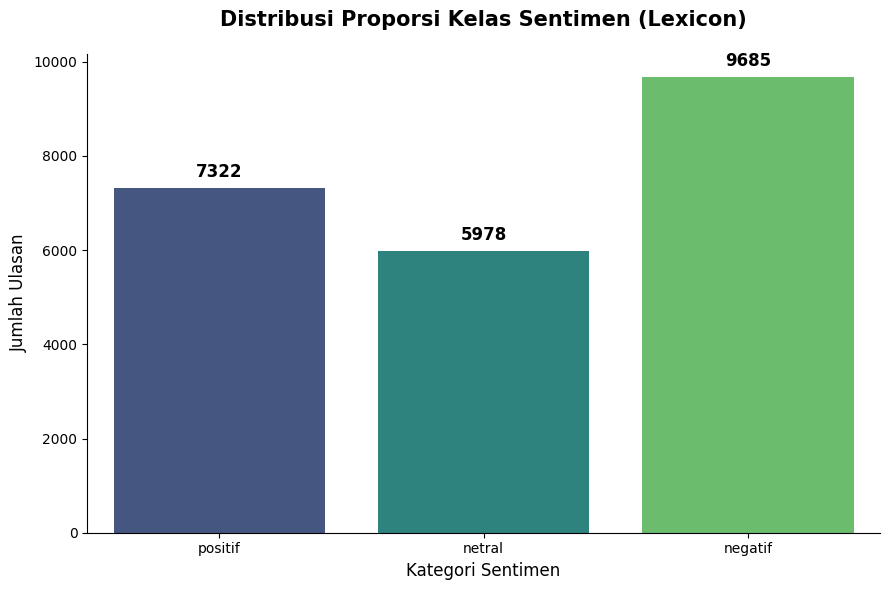

In [167]:
# ==============================================================
# TAHAP 5: PELABELAN OTOMATIS BERDASARKAN LEXICON
# ==============================================================

# Mendefinisikan fungsi perhitungan skor sentimen
def hitung_skor_sentimen(kumpulan_kata):
    skor_total = 0

    # Menjumlahkan poin dari setiap kata yang cocok dengan kamus positif
    for kata in kumpulan_kata:
        if kata in kamus_positif:
            skor_total += kamus_positif[kata]

    # Menambahkan poin dari setiap kata yang cocok dengan kamus negatif
    for kata in kumpulan_kata:
        if kata in kamus_negatif:
            skor_total += kamus_negatif[kata]

    label_sentimen = ''

    # Penentuan label akhir (Ambang batas / Threshold: 0.5)
    if skor_total > 0.5:
        label_sentimen = 'positif'
    elif skor_total < -0.5:
        label_sentimen = 'negatif'
    else:
        label_sentimen = 'netral'

    return skor_total, label_sentimen

print("Mengeksekusi pelabelan otomatis pada dataset. Mohon tunggu...")

# Menerapkan fungsi pada kolom yang sudah di-tokenisasi & di-filter (text_stopword)
hasil_pelabelan = df['text_stopword'].apply(hitung_skor_sentimen)

# Membongkar (unzip) hasil perhitungan menjadi dua kolom terpisah
hasil_unzip = list(zip(*hasil_pelabelan))
df['skor_sentimen'] = hasil_unzip[0]
df['label'] = hasil_unzip[1]

print("✅ Pelabelan selesai!\n")
print("--- Distribusi Label Sentimen (Tabel) ---")
print(df['label'].value_counts())

# ================================
# VISUALISASI HASIL PELABELAN
# ================================
plt.figure(figsize=(9, 6))
# Menggunakan palet warna yang lebih segar dan urutan yang rapi
ax = sns.countplot(data=df, x='label', palette='viridis', order=['positif', 'netral', 'negatif'])

plt.title("Distribusi Proporsi Kelas Sentimen (Lexicon)", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Kategori Sentimen", fontsize=12)
plt.ylabel("Jumlah Ulasan", fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=12, fontweight='bold', color='black', xytext=(0, 5), textcoords='offset points')

# Menghapus garis tepi kanan dan atas agar terlihat lebih clean
sns.despine()
plt.tight_layout()
plt.show()

Membangun dashboard visualisasi Word Cloud berdampingan untuk masing-masing sentimen...



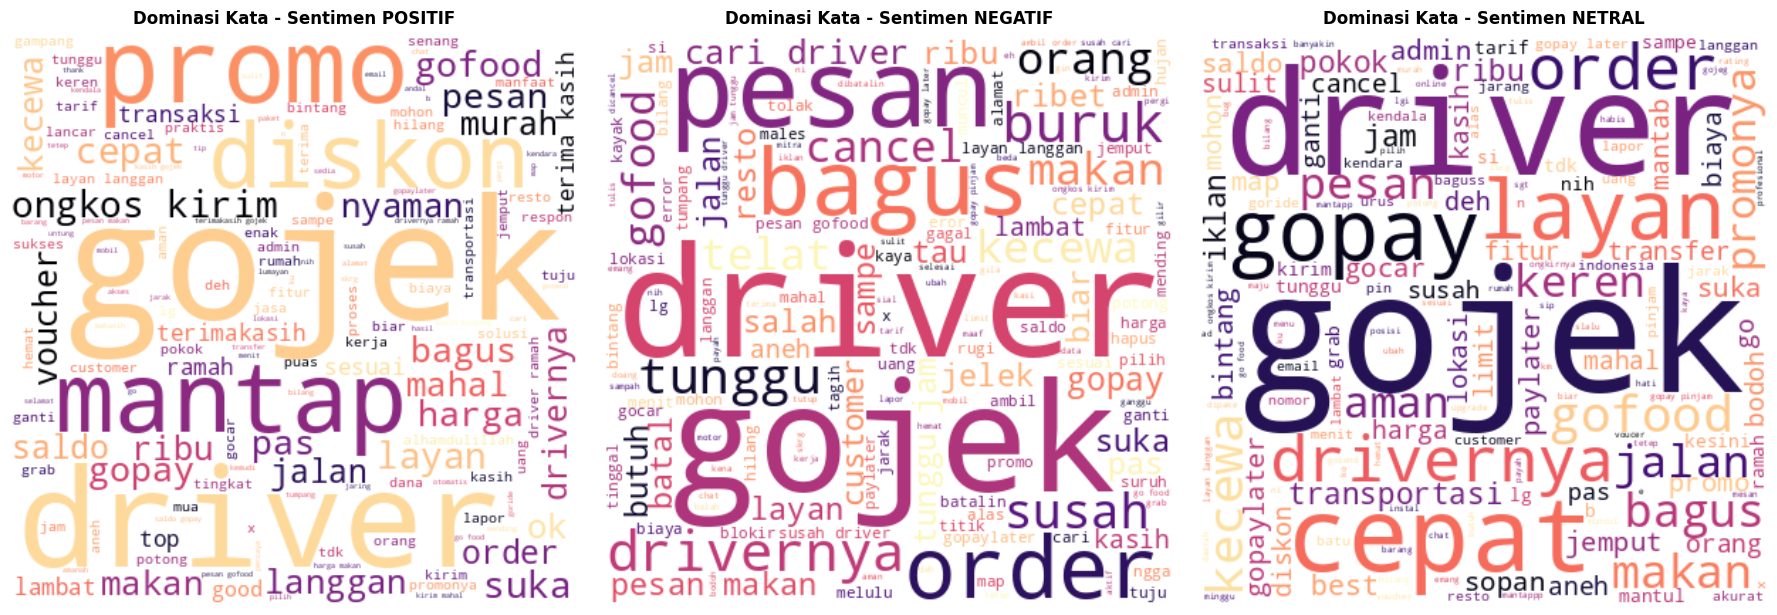

In [168]:
# ==============================================================
# TAHAP 6: EKSPLORASI KATA KUNCI (WORD CLOUD) HORIZONTAL
# ==============================================================
print("Membangun dashboard visualisasi Word Cloud berdampingan untuk masing-masing sentimen...\n")

# Mendefinisikan daftar kelas sentimen yang akan divisualisasikan
daftar_sentimen = ['positif', 'negatif', 'netral']

# 1. Membuat satu gambar (fig) dan tiga sub-plot (axs) secara horizontal
# nrows=1 untuk satu baris, ncols=3 untuk tiga kolom berdampingan
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

# Perulangan untuk mengeksekusi visualisasi secara otomatis tanpa mengulang kode
for i, sentimen in enumerate(daftar_sentimen):
    # 2. Memfilter teks sesuai kategori sentimen
    teks_gabungan = ' '.join(df[df['label'] == sentimen]['text_akhir'].dropna())

    # 3. Mencegah error jika ternyata ada kelas yang kosong
    if len(teks_gabungan) == 0:
        print(f"⚠️ Tidak ada teks untuk sentimen {sentimen}.")
        continue

    # 4. Membangun objek WordCloud
    awan_kata = WordCloud(
        width=400, # Lebar diperkecil agar pas berdampingan
        height=400,
        background_color='white',
        max_words=150,               # Membatasi maksimal 150 kata agar tidak terlalu padat
        colormap='magma',            # Pilihan warna yang estetis
        contour_width=1,
        contour_color='steelblue'
    ).generate(teks_gabungan)

    # 5. Merender visualisasi pada sub-plot yang sesuai (axs[i])
    axs[i].imshow(awan_kata, interpolation='bilinear')

    # 6. Menetapkan judul dinamis pada sub-plot
    axs[i].set_title(f'Dominasi Kata - Sentimen {sentimen.upper()}', fontsize=12, fontweight='bold', pad=10)

    # 7. Menghilangkan garis sumbu X dan Y pada sub-plot agar bersih
    axs[i].axis('off')

# 8. Menata tata letak agar tidak tumpang tindih
plt.tight_layout()

# 9. Menampilkan seluruh dashboard visualisasi secara horizontal
plt.show()

In [169]:
# ==============================================================
# TAHAP 7: EKSTRAKSI FITUR (TF-IDF) & DATA SPLITTING
# ==============================================================
print("1. Memulai proses pembobotan kata (Feature Extraction)...")

# Memisahkan kolom fitur (teks akhir) dan target (label sentimen)
fitur_teks = df['text_akhir']
target_label = df['label']

# Menggunakan metode TF-IDF untuk mengubah teks menjadi representasi angka numerik
vektor_tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words='english'
)

# Mentransformasi keseluruhan teks menjadi matriks
matriks_tfidf = vektor_tfidf.fit_transform(fitur_teks)

# Menampung daftar fitur kosakata ke dalam DataFrame untuk keperluan inspeksi
df_kosakata = pd.DataFrame(matriks_tfidf.toarray(), columns=vektor_tfidf.get_feature_names_out())
print(f"✅ Ekstraksi selesai! Berhasil menangkap {df_kosakata.shape[1]} fitur kosakata unik.")

print("\n2. Membagi dataset (70% Data Latih, 30% Data Uji)...")
# Memecah data dengan teknik stratify agar proporsi kelas (positif/negatif/netral) tetap seimbang
fitur_latih_lr, fitur_uji_lr, target_latih_lr, target_uji_lr = train_test_split(
    matriks_tfidf,
    target_label,
    test_size=0.3,
    random_state=42,
    stratify=target_label
)
print("✅ Pembagian data latih dan uji berhasil dilakukan.")

1. Memulai proses pembobotan kata (Feature Extraction)...
✅ Ekstraksi selesai! Berhasil menangkap 5000 fitur kosakata unik.

2. Membagi dataset (70% Data Latih, 30% Data Uji)...
✅ Pembagian data latih dan uji berhasil dilakukan.


In [170]:
# ==============================================================
# TAHAP 8: MODEL 1 - PELATIHAN LOGISTIC REGRESSION
# ==============================================================
print("Membangun model klasifikasi Logistic Regression...\n")

# Inisialisasi algoritma klasifikasi Machine Learning
model_logreg = LogisticRegression()

# Proses Training (Belajar dari data)
model_logreg.fit(fitur_latih_lr.toarray(), target_latih_lr)

# Melakukan prediksi terhadap Data Latih dan Data Uji
prediksi_latih_lr = model_logreg.predict(fitur_latih_lr.toarray())
prediksi_uji_lr = model_logreg.predict(fitur_uji_lr.toarray())

# Mengukur performa model (Akurasi)
akurasi_latih_lr = accuracy_score(target_latih_lr, prediksi_latih_lr)
akurasi_uji_lr = accuracy_score(target_uji_lr, prediksi_uji_lr)

# Mencetak hasil evaluasi
print('=== EVALUASI PERFORMA LOGISTIC REGRESSION ===')
print(f'Logistic Regression - accuracy_train : {akurasi_latih_lr* 100:.0f}%')
print(f'Logistic Regression - accuracy_test  : {akurasi_uji_lr* 100:.0f}%')

Membangun model klasifikasi Logistic Regression...

=== EVALUASI PERFORMA LOGISTIC REGRESSION ===
Logistic Regression - accuracy_train : 92%
Logistic Regression - accuracy_test  : 87%


In [171]:
# ==============================================================
# TAHAP 9: EKSTRAKSI FITUR (BAG OF WORDS) & DATA SPLITTING
# ==============================================================
print("1. Memulai proses ekstraksi fitur (Bag of Words)...")

# Menggunakan CountVectorizer sesuai desain eksperimen model kedua
vektor_bow = CountVectorizer(
    max_features=15000,
    ngram_range=(1, 1), # Mengekstrak kata tunggal
    min_df=2
)

# Mentransformasi teks menjadi matriks kemunculan kata
# Logika eksperimen: Transformasi dilakukan sebelum pemisahan data
matriks_bow = vektor_bow.fit_transform(df['text_akhir'])

# Menyelaraskan target dengan kolom label kita
target_label_svm = df['label']

print(f"✅ Ekstraksi BoW selesai! Membentuk matriks dengan ukuran: {matriks_bow.shape}")

print("\n2. Membagi dataset (90% Data Latih, 10% Data Uji)...")
# Memecah data latih dan uji menggunakan proporsi 90/10
fitur_latih_svm, fitur_uji_svm, target_latih_svm, target_uji_svm = train_test_split(
    matriks_bow,
    target_label_svm,
    test_size=0.1,
    random_state=42,
    stratify=target_label_svm
)
print("✅ Pembagian data latih dan uji untuk SVM berhasil dilakukan.")

1. Memulai proses ekstraksi fitur (Bag of Words)...
✅ Ekstraksi BoW selesai! Membentuk matriks dengan ukuran: (22985, 5579)

2. Membagi dataset (90% Data Latih, 10% Data Uji)...
✅ Pembagian data latih dan uji untuk SVM berhasil dilakukan.


In [155]:
# ==============================================================
# TAHAP 10: MODEL 2 - PELATIHAN SUPPORT VECTOR MACHINE (SVM)
# ==============================================================
print("Membangun model klasifikasi Support Vector Machine (SVM)...\n")

# Inisialisasi algoritma SVM dengan hyperparameter spesifik
model_svm = SVC(
    C=2,                     # Parameter penalti margin
    kernel='linear',         # Menggunakan pemisah garis lurus (linear)
    class_weight='balanced',  # Menyeimbangkan bobot antar kelas secara otomatis
    random_state=42
)

# Proses Training (Belajar dari data)
model_svm.fit(fitur_latih_svm, target_latih_svm)

# Melakukan prediksi terhadap Data Latih dan Data Uji
prediksi_latih_svm = model_svm.predict(fitur_latih_svm)
prediksi_uji_svm = model_svm.predict(fitur_uji_svm)

# Mengukur performa model (Akurasi)
akurasi_latih_svm = accuracy_score(target_latih_svm, prediksi_latih_svm)
akurasi_uji_svm = accuracy_score(target_uji_svm, prediksi_uji_svm)

# Mencetak hasil evaluasi
print('=== EVALUASI PERFORMA SUPPORT VECTOR MACHINE ===')
print(f'SVM - accuracy_train : {akurasi_latih_svm * 100:.0f}%')
print(f'SVM - accuracy_test  : {akurasi_uji_svm * 100:.0f}%')

Membangun model klasifikasi Support Vector Machine (SVM)...

=== EVALUASI PERFORMA SUPPORT VECTOR MACHINE ===
SVM - accuracy_train : 98%
SVM - accuracy_test  : 92%


In [156]:
# ==============================================================
# TAHAP 11: EKSTRAKSI FITUR & PERSIAPAN DATA (DEEP LEARNING)
# ==============================================================
print("1. Mengeksekusi TF-IDF untuk Jaringan Saraf Tiruan (ANN)...")

# Menggunakan TfidfVectorizer dengan ngram_range (1,2)
vektorizer_tfidf_ann = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

# Transformasi teks menjadi matriks probabilitas TF-IDF
matriks_tfidf_ann = vektorizer_tfidf_ann.fit_transform(df['text_akhir'])

print("\n2. Membagi dataset (80% Data Latih, 20% Data Uji)...")
# Pemisahan dataset dengan rasio 80/20
fitur_latih_ann, fitur_uji_ann, target_latih_ann, target_uji_ann = train_test_split(
    matriks_tfidf_ann,
    df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

print("\n3. Encoding Label Sentimen (One-Hot Encoding)...")
# Algoritma ANN Keras membutuhkan label berupa angka kategorikal matriks
pengkode_label = LabelEncoder()

# Mengubah teks (positif/negatif/netral) menjadi angka (0, 1, 2)
target_latih_angka = pengkode_label.fit_transform(target_latih_ann)
target_uji_angka = pengkode_label.transform(target_uji_ann)

# Menghitung jumlah kelas unik yang ada
jumlah_kelas_sentimen = len(pengkode_label.classes_)

# Mengubah angka menjadi format matriks One-Hot (to_categorical)
target_latih_ohe = to_categorical(target_latih_angka, num_classes=jumlah_kelas_sentimen)
target_uji_ohe = to_categorical(target_uji_angka, num_classes=jumlah_kelas_sentimen)

print(f"✅ Data siap disuapkan ke dalam Model ANN! Terdeteksi {jumlah_kelas_sentimen} kelas sentimen.")

1. Mengeksekusi TF-IDF untuk Jaringan Saraf Tiruan (ANN)...

2. Membagi dataset (80% Data Latih, 20% Data Uji)...

3. Encoding Label Sentimen (One-Hot Encoding)...
✅ Data siap disuapkan ke dalam Model ANN! Terdeteksi 3 kelas sentimen.


In [157]:
# ==============================================================
# TAHAP 12: MODEL 3 - PELATIHAN ARTIFICIAL NEURAL NETWORK (ANN)
# ==============================================================
print("Membangun arsitektur Deep Learning (ANN)...\n")

# Inisialisasi model Sequential berurutan
model_jaringan_saraf = Sequential()

# Layer Input: Lebar pintu masuk disesuaikan dengan jumlah kolom fitur TF-IDF (5000)
model_jaringan_saraf.add(Input(shape=(fitur_latih_ann.shape[1],)))

# Hidden Layer 1: 128 Neuron
model_jaringan_saraf.add(Dense(128, activation='relu'))

# Hidden Layer 2: 64 Neuron
model_jaringan_saraf.add(Dense(64, activation='relu'))

# Layer Output: Menggunakan Softmax untuk klasifikasi Multi-Kelas
model_jaringan_saraf.add(Dense(jumlah_kelas_sentimen, activation='softmax'))

# Kompilasi Model
model_jaringan_saraf.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks: Menghentikan pelatihan jika tidak ada perkembangan untuk menghemat waktu & mencegah overfitting
penghenti_dini = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

print("Memulai proses pelatihan model (Training Iteration)...")
# Fit Model: sparse matrix harus dikonversi ke array padat (dense) untuk standar Keras TensorFlow
riwayat_pelatihan = model_jaringan_saraf.fit(
    fitur_latih_ann.toarray(), target_latih_ohe,
    validation_data=(fitur_uji_ann.toarray(), target_uji_ohe),
    epochs=10,
    batch_size=32,
    callbacks=[penghenti_dini]
)

# Mengukur performa model akhir menggunakan evaluasi
# (verbose=0 agar log output tidak berantakan)
akurasi_latih_ann = model_jaringan_saraf.evaluate(fitur_latih_ann.toarray(), target_latih_ohe, verbose=0)[1]
akurasi_uji_ann = model_jaringan_saraf.evaluate(fitur_uji_ann.toarray(), target_uji_ohe, verbose=0)[1]

# Mencetak hasil evaluasi final
print('\n=== EVALUASI PERFORMA DEEP LEARNING (ANN) ===')
print(f'ANN (Deep Learning) - accuracy_train : {akurasi_latih_ann* 100:.0f}%')
print(f'ANN (Deep Learning) - accuracy_test  : {akurasi_uji_ann* 100:.0f}%')

Membangun arsitektur Deep Learning (ANN)...

Memulai proses pelatihan model (Training Iteration)...
Epoch 1/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.7916 - loss: 0.5197 - val_accuracy: 0.8804 - val_loss: 0.3480
Epoch 2/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.9341 - loss: 0.2019 - val_accuracy: 0.8710 - val_loss: 0.3731
Epoch 3/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9631 - loss: 0.1211 - val_accuracy: 0.8834 - val_loss: 0.3794
Epoch 4/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9803 - loss: 0.0788 - val_accuracy: 0.8791 - val_loss: 0.4270

=== EVALUASI PERFORMA DEEP LEARNING (ANN) ===
ANN (Deep Learning) - accuracy_train : 94%
ANN (Deep Learning) - accuracy_test  : 88%


Merekapitulasi hasil evaluasi seluruh model...

=== TABEL PERBANDINGAN PERFORMA MODEL ===


,Algoritma,Akurasi Training (%),Akurasi Testing (%),GAP Overfitting (%)
0,Regresi Logistik,92%,87%,5%
1,Support Vector Machine,98%,92%,6%
2,Deep Learning (ANN),94%,88%,6%


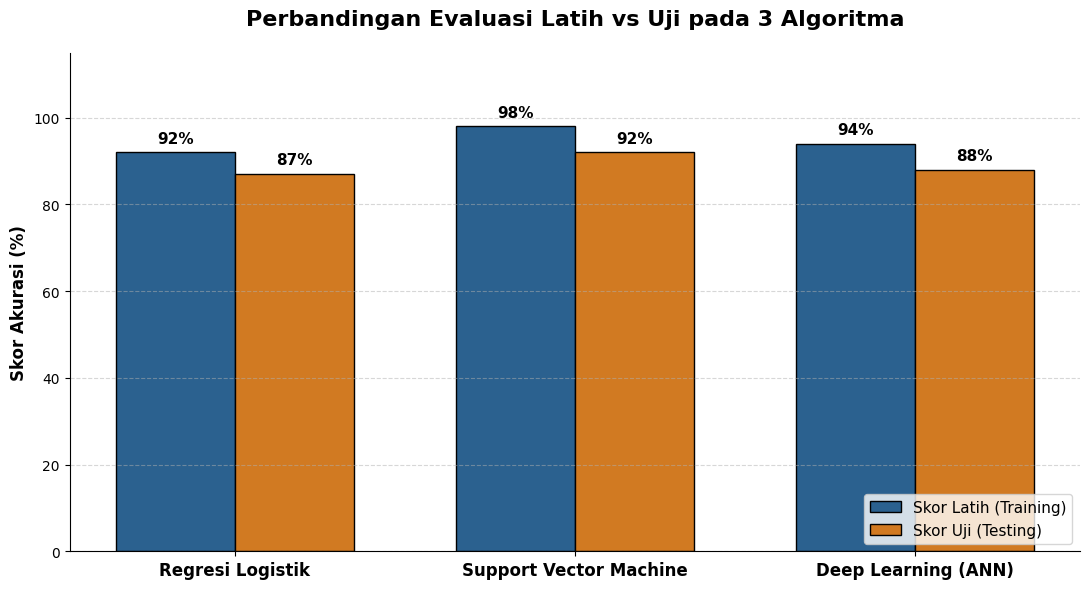


🏆 KESIMPULAN AKHIR PENELITIAN:
Berdasarkan pengujian komparatif di atas, algoritma TERBAIK untuk menganalisis sentimen pada dataset ini adalah 'SUPPORT VECTOR MACHINE'.
Model ini berhasil memimpin dengan pencapaian Akurasi Testing tertinggi sebesar 92%.


In [158]:
# ==============================================================
# TAHAP 13: KOMPARASI KINERJA MODEL & KESIMPULAN AKHIR
# ==============================================================
print("Merekapitulasi hasil evaluasi seluruh model...\n")

# 1. Menyatukan seluruh hasil evaluasi ke dalam satu kamus data (Dictionary)
data_rekapan = {
    'Algoritma': ['Regresi Logistik', 'Support Vector Machine', 'Deep Learning (ANN)'],
    'Akurasi Training (%)': [round(akurasi_latih_lr * 100), round(akurasi_latih_svm * 100), round(akurasi_latih_ann * 100)],
    'Akurasi Testing (%)': [round(akurasi_uji_lr * 100), round(akurasi_uji_svm * 100), round(akurasi_uji_ann * 100)]
}

# 2. Mengubah dictionary menjadi DataFrame Pandas
tabel_komparasi = pd.DataFrame(data_rekapan)

# 3. Menghitung Jurang Overfitting (Selisih Akurasi Latih dan Uji)
tabel_komparasi['GAP Overfitting (%)'] = tabel_komparasi['Akurasi Training (%)'] - tabel_komparasi['Akurasi Testing (%)']

print("=== TABEL PERBANDINGAN PERFORMA MODEL ===")
# Membuat salinan khusus untuk tampilan agar data asli (angka) tidak rusak untuk grafik
tabel_tampil = tabel_komparasi.copy()
kolom_persen = ['Akurasi Training (%)', 'Akurasi Testing (%)', 'GAP Overfitting (%)']

for kolom in kolom_persen:
    tabel_tampil[kolom] = tabel_tampil[kolom].astype(str) + '%'

display(tabel_tampil)

# ================================
# VISUALISASI GRAFIK KOMPARASI
# ================================
posisi_x = np.arange(len(tabel_komparasi['Algoritma']))
lebar_batang = 0.35

fig, ax = plt.subplots(figsize=(11, 6))

# Menggambar grafik batang (Tetap menggunakan tabel_komparasi yang berisi angka asli)
batang_latih = ax.bar(posisi_x - lebar_batang/2, tabel_komparasi['Akurasi Training (%)'],
                      lebar_batang, label='Skor Latih (Training)', color='#2b618f', edgecolor='black')
batang_uji = ax.bar(posisi_x + lebar_batang/2, tabel_komparasi['Akurasi Testing (%)'],
                    lebar_batang, label='Skor Uji (Testing)', color='#d17a22', edgecolor='black')

ax.set_ylabel('Skor Akurasi (%)', fontsize=12, fontweight='bold')
ax.set_title('Perbandingan Evaluasi Latih vs Uji pada 3 Algoritma', fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(posisi_x)
ax.set_xticklabels(tabel_komparasi['Algoritma'], fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.set_ylim(0, 115)

def tempel_label(kumpulan_batang):
    for batang in kumpulan_batang:
        tinggi = batang.get_height()
        ax.annotate(f'{tinggi:.0f}%',
                    xy=(batang.get_x() + batang.get_width() / 2, tinggi),
                    xytext=(0, 5),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

tempel_label(batang_latih)
tempel_label(batang_uji)

plt.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine()
plt.tight_layout()
plt.show()

# ================================
# DEKLARASI MODEL TERBAIK
# ================================
index_terbaik = tabel_komparasi['Akurasi Testing (%)'].idxmax()
nama_juara = tabel_komparasi.loc[index_terbaik, 'Algoritma']
skor_juara = tabel_komparasi.loc[index_terbaik, 'Akurasi Testing (%)']

print(f"\n🏆 KESIMPULAN AKHIR PENELITIAN:")
print(f"Berdasarkan pengujian komparatif di atas, algoritma TERBAIK untuk menganalisis sentimen pada dataset ini adalah '{nama_juara.upper()}'.")
print(f"Model ini berhasil memimpin dengan pencapaian Akurasi Testing tertinggi sebesar {skor_juara:.0f}%.")

In [159]:
# ==============================================================
# TAHAP 14: SIMULASI PREDIKSI (INFERENCE) DENGAN TEKS BARU
# ==============================================================
print("Mempersiapkan sistem prediksi kalimat baru...\n")

# 1. Menyatukan seluruh proses pembersihan ke dalam satu pintu (Pipeline)
def pipeline_pembersihan_teks(teks_mentah):
    teks = bersihkan_teks(teks_mentah)
    teks = turunkan_huruf(teks)
    teks = perbaiki_kata_gaul(teks)
    token = potong_kata(teks)
    tersaring = saring_kata(token)
    teks_final = gabung_ke_kalimat(tersaring)
    return teks_final

# 2. Membuat fungsi khusus untuk langsung memprediksi dan mencetak hasil
def uji_sentimen_baru(teks_baru):
    print(f"Teks Input    : '{teks_baru}'")

    # Proses A: Bersihkan teks
    teks_bersih = pipeline_pembersihan_teks(teks_baru)
    print(f"Teks Bersih   : '{teks_bersih}'")

    # Proses B: Ubah teks bersih menjadi vektor angka
    vektor_teks = vektor_bow.transform([teks_bersih])

    # Proses C: Tebak sentimen menggunakan model
    hasil_prediksi = model_svm.predict(vektor_teks)

    # Cetak Hasil dengan gaya visual yang menarik
    print(f"👉 PREDIKSI   : [ {hasil_prediksi[0].upper()} ]")
    print("-" * 60)

# ================================
# MARI KITA UJI MODELNYA!
# ================================
print("=== PENGUJIAN MODEL DENGAN ULASAN GOJEK BARU ===\n")

# Uji 1: Ulasan Negatif
teks_negatif = "Parah banget aplikasinya ngelag, drivernya juga lama muter-muter ga jelas."
uji_sentimen_baru(teks_negatif)

# Uji 2: Ulasan Positif
teks_positif = "Wah gila sih, dapet promo banyak banget dari GoFood. Makanannya juga cepet sampainya!"
uji_sentimen_baru(teks_positif)

# Uji 3: Ulasan Netral
teks_netral = "Saya hanya download dan pakai aplikasi ini buat bayar tagihan listrik tiap bulan."
uji_sentimen_baru(teks_netral)

Mempersiapkan sistem prediksi kalimat baru...

=== PENGUJIAN MODEL DENGAN ULASAN GOJEK BARU ===

Teks Input    : 'Parah banget aplikasinya ngelag, drivernya juga lama muter-muter ga jelas.'
Teks Bersih   : 'buruk ngelag drivernya mutermuter'
👉 PREDIKSI   : [ NEGATIF ]
------------------------------------------------------------
Teks Input    : 'Wah gila sih, dapet promo banyak banget dari GoFood. Makanannya juga cepet sampainya!'
Teks Bersih   : 'gila promo gofood makanannya cepat sampainya'
👉 PREDIKSI   : [ POSITIF ]
------------------------------------------------------------
Teks Input    : 'Saya hanya download dan pakai aplikasi ini buat bayar tagihan listrik tiap bulan.'
Teks Bersih   : 'tagihan listrik'
👉 PREDIKSI   : [ NETRAL ]
------------------------------------------------------------


🏆 Kesimpulan Akhir Eksperimen Pemodelan
Berdasarkan rekapitulasi hasil evaluasi pemodelan pada tabel di atas, kita dapat menarik analisis komparatif mengenai performa ketiga algoritma sebagai berikut:

🥇 Support Vector Machine (SVM) - (Model Terbaik):
SVM terbukti menjadi algoritma yang paling tangguh dan optimal untuk dataset ini. Model ini tidak hanya memimpin perolehan akurasi Training (98%), tetapi juga sukses meraih akurasi Testing tertinggi di angka 92%. Meskipun terdapat GAP overfitting sebesar 6%, angka ini masih tergolong wajar dan sangat terbayar oleh tingginya persentase tebakan benarnya pada data baru.

🥈 Deep Learning (ANN) - (Posisi Kedua):
Artificial Neural Network menempati posisi kedua dengan akurasi Training 94% dan Testing 88%. Namun, hal yang perlu menjadi catatan adalah model ini memiliki jurang (GAP) overfitting tertinggi sebesar 6%. Hal ini merupakan karakteristik umum Deep Learning yang cenderung terlalu cepat menghafal data training, terutama jika jumlah dataset tidak dalam skala masif ratusan ribu baris.

🥉 Logistic Regression - (Model Paling Stabil):
Meskipun Logistic Regression menempati urutan terakhir dalam hal akurasi mentah (Testing 87%), model dasar ini layak mendapat apresiasi karena merupakan model yang paling stabil. Hal ini dibuktikan dengan GAP overfitting yang paling kecil, yaitu hanya 5%. Ini menunjukkan bahwa Logistic Regression sangat konsisten performanya, baik saat latihan maupun ujian.